# Wearable Heart Rate – Time Series Analysis
**Student:** Darshan Morkar  
**Dataset:** `wearable_hr_realistic.csv` – Heart Rate sampled at 5-second intervals over ~30 minutes

---
## Task 1 – Load the Sensor Signal and Describe the Time Series

Number of observations : 360
Sampling interval      : 5 seconds
Duration               : 29.9 minutes
Mean heart rate        : 104.84 bpm
Standard deviation     : 29.12 bpm
Minimum / Maximum      : 62.0 / 160.0 bpm


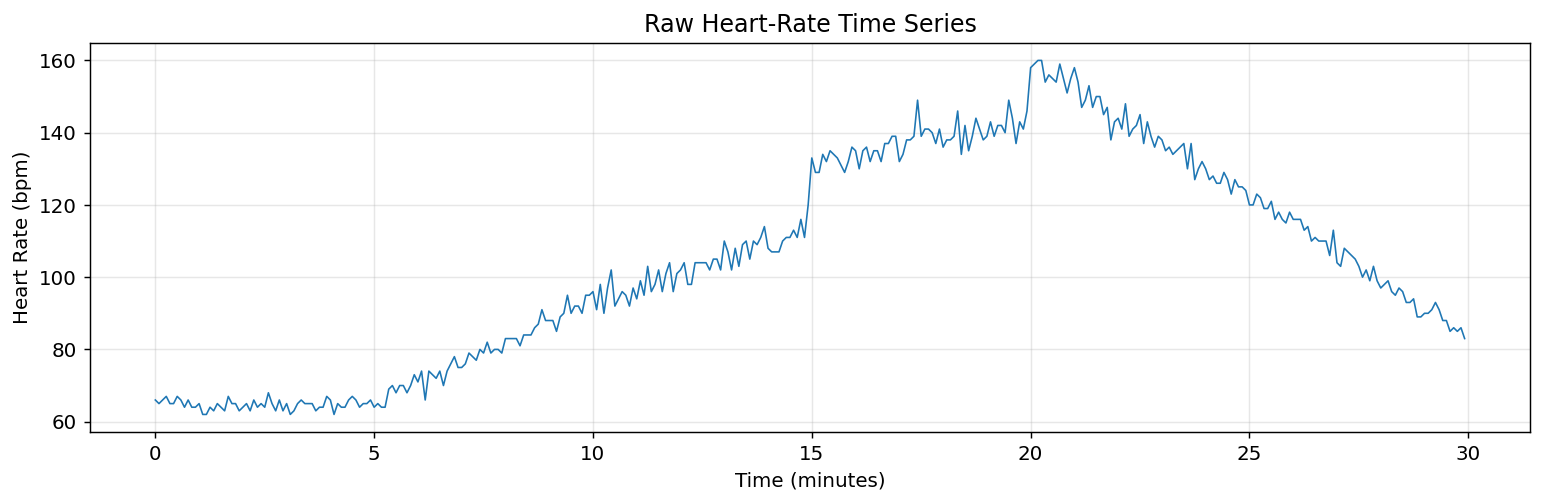

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})

# Load the one-dimensional heart-rate signal
# The CSV file should be in the same folder as this notebook.
df = pd.read_csv('wearable_hr_realistic.csv')
df.columns = ['Time', 'HeartRate']

hr = df['HeartRate'].astype(float).to_numpy()
n = len(hr)
t_min = np.arange(n) * 5 / 60  # 5-second sampling interval, expressed in minutes

print(f"Number of observations : {n}")
print(f"Sampling interval      : 5 seconds")
print(f"Duration               : {t_min[-1]:.1f} minutes")
print(f"Mean heart rate        : {hr.mean():.2f} bpm")
print(f"Standard deviation     : {hr.std(ddof=1):.2f} bpm")
print(f"Minimum / Maximum      : {hr.min():.1f} / {hr.max():.1f} bpm")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t_min, hr, linewidth=0.9)
ax.set_title('Raw Heart-Rate Time Series')
ax.set_xlabel('Time (minutes)')
ax.set_ylabel('Heart Rate (bpm)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('task1_raw_series.png', bbox_inches='tight')
plt.show()

**Interpretation:** The data form a univariate time series because one sensor variable, heart rate in beats per minute, is observed repeatedly at equal 5-second intervals. The raw plot should be used to describe trend, local fluctuations, possible outliers, and any short transient episodes. A changing mean over time would indicate that the original signal is probably not stationary.

---
## Task 2 – Assess Stationarity Visually and with Statistical Tests

In [5]:
# ADF test: H0 = unit root / non-stationary
adf_stat, adf_p, adf_lags, adf_nobs, adf_cv, _ = adfuller(hr, autolag='AIC')

print('Augmented Dickey-Fuller test on raw series')
print(f'ADF statistic : {adf_stat:.4f}')
print(f'p-value       : {adf_p:.4f}')
print(f'lags used     : {adf_lags}')
for level, value in adf_cv.items():
    print(f'critical value {level}: {value:.4f}')

print('KPSS test on raw series')
# KPSS test: H0 = level-stationary
kpss_stat, kpss_p, kpss_lags, kpss_cv = kpss(hr, regression='c', nlags='auto')
print(f'KPSS statistic: {kpss_stat:.4f}')
print(f'p-value       : {kpss_p:.4f}')
print(f'lags used     : {kpss_lags}')
for level, value in kpss_cv.items():
    print(f'critical value {level}: {value:.4f}')

Augmented Dickey-Fuller test on raw series
ADF statistic : -1.2830
p-value       : 0.6369
lags used     : 11
critical value 1%: -3.4493
critical value 5%: -2.8699
critical value 10%: -2.5712
KPSS test on raw series
KPSS statistic: 1.9385
p-value       : 0.0100
lags used     : 11
critical value 10%: 0.3470
critical value 5%: 0.4630
critical value 2.5%: 0.5740
critical value 1%: 0.7390


**Interpretation:** If the ADF p-value is above 0.05, we fail to reject the unit-root null hypothesis. If the KPSS p-value is below 0.05, we reject level stationarity. Together with the raw plot, this provides evidence on whether the original heart-rate signal can be modelled directly or first requires transformation.

---
## Task 3 – Transform the Series to Improve Stationarity

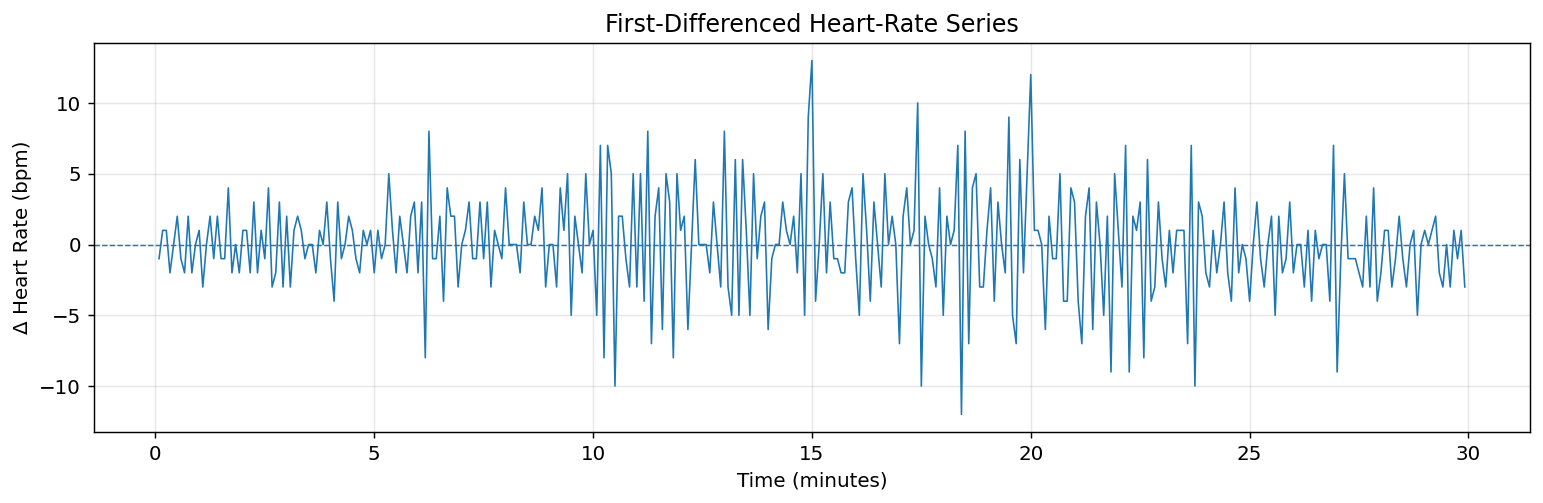

Stationarity tests after first differencing
ADF statistic : -4.0430, p-value: 0.0012
KPSS statistic: 0.7979, p-value: 0.0100


In [6]:
# First-order differencing: Δy_t = y_t - y_(t-1)
hr_diff = np.diff(hr, n=1)
t_diff = t_min[1:]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t_diff, hr_diff, linewidth=0.9)
ax.axhline(0, linestyle='--', linewidth=0.8)
ax.set_title('First-Differenced Heart-Rate Series')
ax.set_xlabel('Time (minutes)')
ax.set_ylabel('Δ Heart Rate (bpm)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('task3_differenced_series.png', bbox_inches='tight')
plt.show()

adf_diff = adfuller(hr_diff, autolag='AIC')
kpss_diff = kpss(hr_diff, regression='c', nlags='auto')

print('Stationarity tests after first differencing')
print(f'ADF statistic : {adf_diff[0]:.4f}, p-value: {adf_diff[1]:.4f}')
print(f'KPSS statistic: {kpss_diff[0]:.4f}, p-value: {kpss_diff[1]:.4f}')

**Interpretation:** First-order differencing is appropriate when the raw series has a changing mean or trend. After differencing, the series should fluctuate around zero. If the ADF result becomes significant and the KPSS result improves, the differenced signal can be treated as approximately stationary for ARMA/ARIMA modelling. A log transformation is not necessary unless variance clearly increases with the level of the signal.

---
## Task 4 – Use ACF and PACF to Choose a First Model Candidate

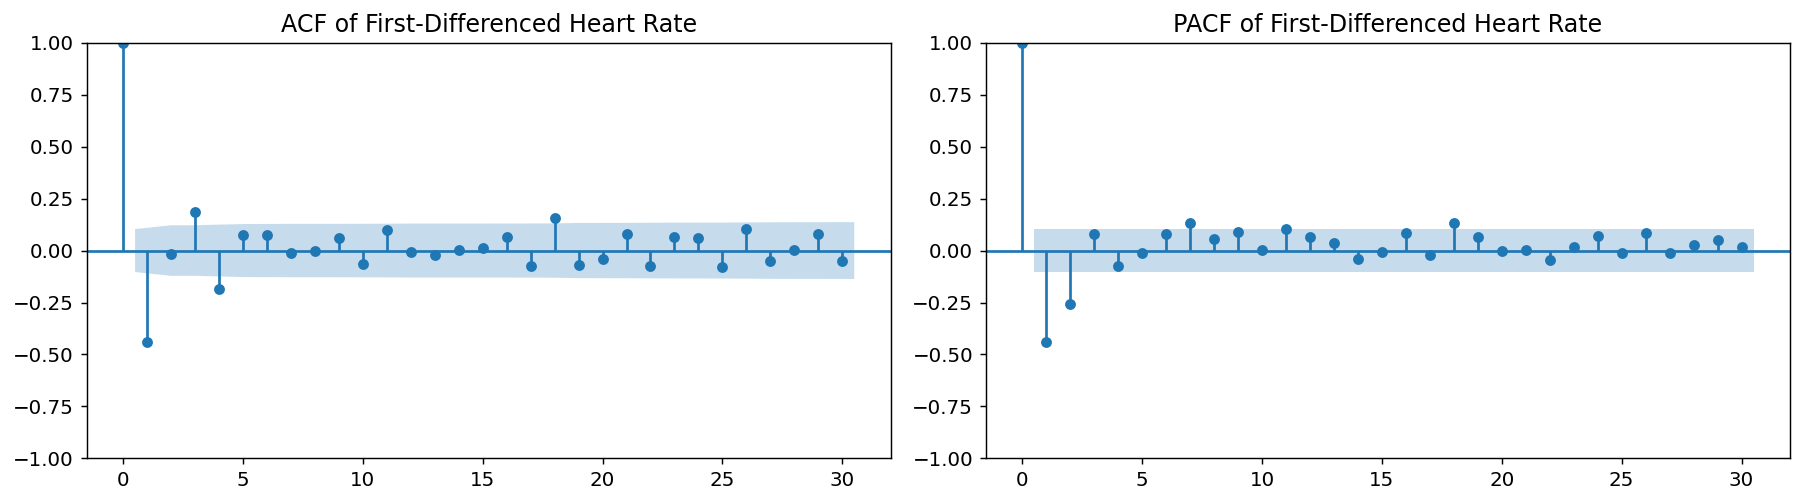

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(hr_diff, lags=30, ax=axes[0])
axes[0].set_title('ACF of First-Differenced Heart Rate')
plot_pacf(hr_diff, lags=30, ax=axes[1], method='ywm')
axes[1].set_title('PACF of First-Differenced Heart Rate')
plt.tight_layout()
plt.savefig('task4_acf_pacf.png', bbox_inches='tight')
plt.show()

**Interpretation:** The ACF and PACF plots are used to justify a parsimonious ARIMA model. A strong lag-1 ACF with little remaining structure supports a simple moving-average component after differencing, giving **ARIMA(0,1,1)** as a suitable first candidate. If instead the PACF cuts off sharply at lag 1, **ARIMA(1,1,0)** would also be a reasonable comparison model. The final choice should be based on the plotted pattern and residual diagnostics.

---
## Task 5 – Fit the ARIMA Model and Inspect Residuals

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  360
Model:                 ARIMA(0, 1, 1)   Log Likelihood                -930.150
Date:                Mon, 27 Apr 2026   AIC                           1864.300
Time:                        19:03:17   BIC                           1872.066
Sample:                             0   HQIC                          1867.388
                                - 360                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.4837      0.038    -12.829      0.000      -0.558      -0.410
sigma2        10.4152      0.539     19.320      0.000       9.359      11.472
Ljung-Box (L1) (Q):                   1.16   Jarque-

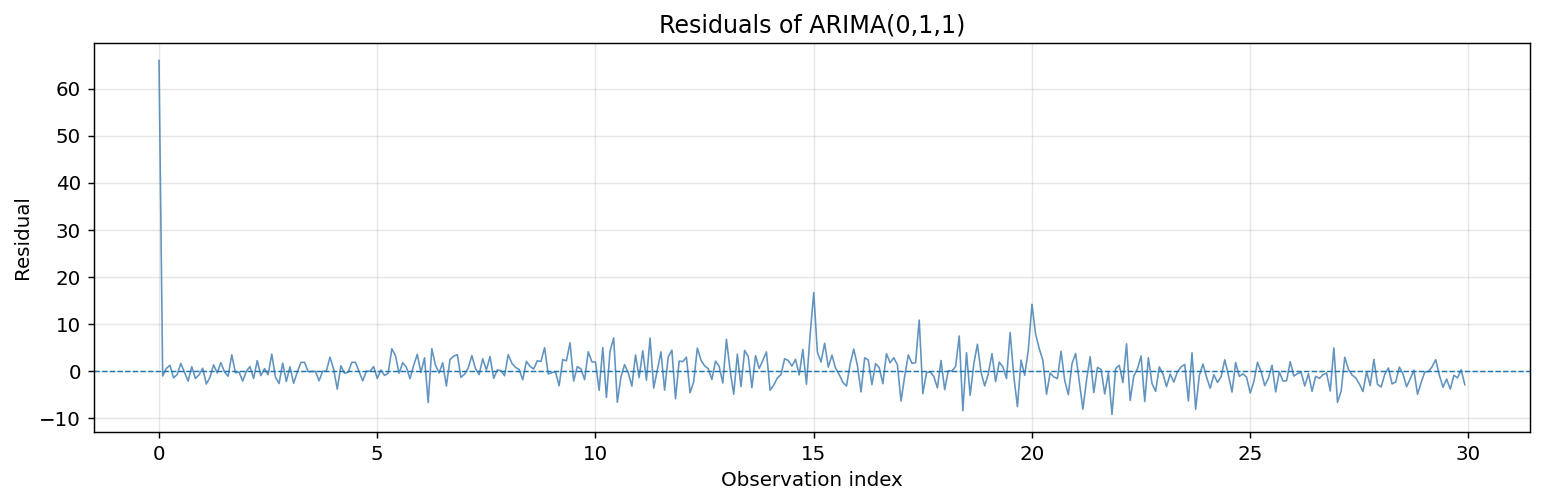

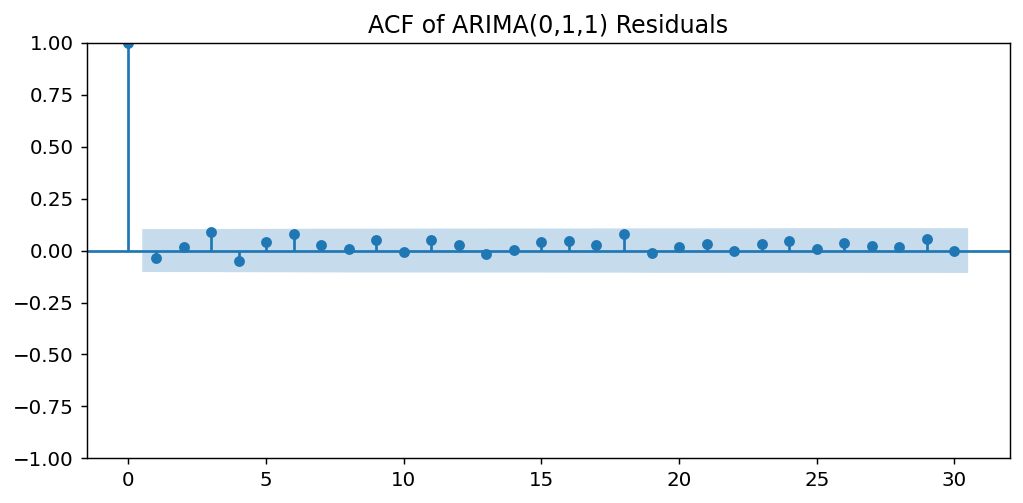

Ljung-Box test for residual autocorrelation
      lb_stat  lb_pvalue
10   8.412817   0.588581
20  13.973517   0.831836


In [ ]:
# Fit ARIMA(0,1,1) on the original series.
# This is equivalent to an MA(1) model on the first difference.
model = ARIMA(hr, order=(0, 1, 1))
result = model.fit()
print(result.summary())

resid = result.resid

fig, ax = plt.subplots(figsize=(12, 4))
# ax.plot(np.arange(len(resid)), resid, linewidth=0.9)
ax.plot(t_min, resid, color='steelblue', linewidth=0.9, alpha=0.85)
ax.axhline(0, linestyle='--', linewidth=0.8)
ax.set_title('Residuals of ARIMA(0,1,1)')
ax.set_xlabel('Time (minutes)')
ax.set_ylabel('Residual')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('task5_residuals_arima_011.png', bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
plot_acf(resid, lags=30, ax=ax)
ax.set_title('ACF of ARIMA(0,1,1) Residuals')
plt.tight_layout()
plt.savefig('task5_residual_acf.png', bbox_inches='tight')
plt.show()

print('Ljung-Box test for residual autocorrelation')
print(acorr_ljungbox(resid, lags=[10, 20], return_df=True))

**Interpretation:** The ARIMA(0,1,1) model is fitted to the original non-stationary series with one order of differencing included inside the model. The residual plot should fluctuate around zero without a remaining trend. Isolated large residuals may occur during sudden physiological changes or sensor artifacts. The residual ACF and Ljung-Box test indicate whether substantial autocorrelation remains; if most residual autocorrelations lie within the confidence limits, the simple model has captured the main short-term dependence.

---
## Task 6 – Reflect on Classical Time-Series Models in Embedded Intelligence

Classical models such as ARIMA are useful in embedded intelligence because they are lightweight, interpretable, and suitable for real-time monitoring. A wearable device can update a one-step-ahead prediction and use the residual as a simple anomaly score without requiring a large neural network or cloud computation.

The main limitation is that ARIMA is linear and univariate. It cannot fully represent exercise phases, motion artifacts, context such as activity type, or non-Gaussian bursts in heart rate. Therefore, ARIMA is a good baseline for compact embedded systems, but more robust models or additional sensor channels may be needed for reliable medical or high-intensity activity monitoring.